
RESTORING CORRUPTED IMAGE

1. Using TV denoising (for noise)...
Denoising converged after 1 iterations

2. Using automatic mask detection...
Image shape: (318, 387, 3)
Image dtype: uint8
Unknown corruption type. Trying multiple approaches...
Denoising converged after 1 iterations
Iteration 0, TV: 3714087.0000, Change: 0.000960
Iteration 100, TV: 29011674.0000, Change: 0.001941
Iteration 200, TV: 66271304.0000, Change: 0.001950


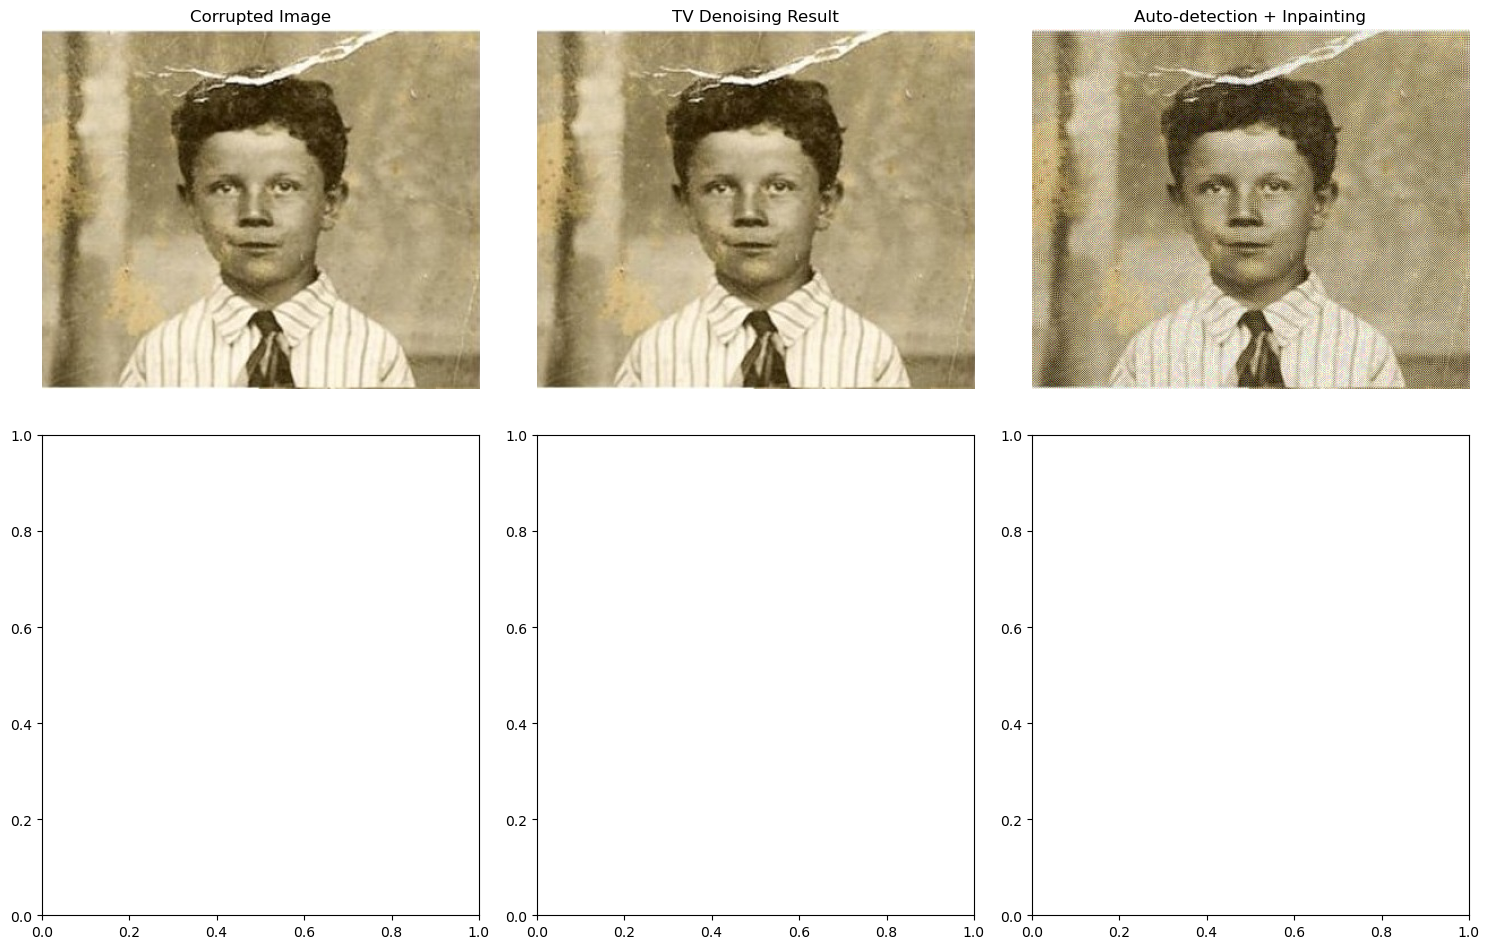

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

def detect_corrupted_regions(image, method='threshold', threshold_value=0):
    """
    Automatically detect corrupted regions in an image
    
    Parameters:
    - image: input image (possibly corrupted)
    - method: detection method ('threshold', 'edge', 'color')
    - threshold_value: threshold for detecting corrupted pixels
    """
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    
    if method == 'threshold':
        # Detect black or white corrupted regions
        corrupted = np.zeros_like(gray, dtype=np.float32)
        
        # Very dark pixels (possible missing data)
        corrupted[gray < threshold_value] = 0
        
        # Very bright pixels (possible corrupted)
        corrupted[gray > 255 - threshold_value] = 0
        
        # By default, everything else is known (1)
        corrupted = 1 - (corrupted == 0).astype(np.float32)
        
    elif method == 'edge':
        # Detect regions with unnatural edges
        edges = cv2.Canny(gray, 50, 150)
        # Dilate edges to get regions
        kernel = np.ones((5,5), np.uint8)
        corrupted_regions = cv2.dilate(edges, kernel, iterations=2)
        corrupted = 1 - (corrupted_regions > 0).astype(np.float32)
        
    elif method == 'color':
        # For color images, detect unusual color combinations
        if len(image.shape) == 3:
            # Convert to HSV for better color analysis
            hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
            # Detect saturated or unusual colors
            corrupted = np.ones(gray.shape, dtype=np.float32)
            # This is a simple example - you'd need to customize based on your corruption
        else:
            corrupted = np.ones(gray.shape, dtype=np.float32)
    
    return corrupted

def tv_denoising(f, lambda_tv=0.6, max_iter=1000, tol=1e-4):
    """
    Total Variation denoising (ROF model) for images with noise
    min_u ||u - f||^2 + λ * TV(u)
    """
    u = f.copy().astype(np.float32)
    step_size = 0.1
    
    tv_values = []
    
    for iteration in range(max_iter):
        u_old = u.copy()
        
        # Compute gradient of TV norm
        grad_tv = gradient_tv(u)
        
        # Data term gradient (2*(u - f))
        grad_data = 2 * (u - f)
        
        # Combined gradient
        grad = grad_data + lambda_tv * grad_tv
        
        # Gradient descent
        u = u - step_size * grad
        
        # Compute TV value for monitoring
        tv_val = total_variation_norm(u)
        tv_values.append(tv_val)
        
        # Check convergence
        diff = np.linalg.norm(u - u_old) / np.linalg.norm(u_old + 1e-10)
        if diff < tol:
            print(f"Denoising converged after {iteration + 1} iterations")
            break
            
        if iteration % 20 == 0:
            print(f"Iteration {iteration}, TV: {tv_val:.4f}, Change: {diff:.6f}")
    
    return np.clip(u, 0, 255).astype(np.uint8), tv_values

def total_variation_norm(u):
    """Compute Total Variation norm"""
    dx = np.diff(u, axis=1, prepend=u[:, :1])
    dy = np.diff(u, axis=0, prepend=u[:1, :])
    tv = np.sum(np.abs(dx)) + np.sum(np.abs(dy))
    return tv

def gradient_tv(u):
    """Compute gradient of TV norm"""
    # Forward differences
    dx = np.diff(u, axis=1, append=u[:, -1:])
    dy = np.diff(u, axis=0, append=u[-1:, :])
    
    # Backward differences for gradient computation
    dx_back = np.diff(u, axis=1, prepend=u[:, :1])
    dy_back = np.diff(u, axis=0, prepend=u[:1, :])
    
    # Gradient of TV norm
    grad = np.zeros_like(u)
    
    # Handle different dimensions
    if len(u.shape) == 3:
        for c in range(u.shape[2]):
            sign_dx = np.sign(dx_back[:, :, c])
            sign_dy = np.sign(dy_back[:, :, c])
            
            grad[:, :-1, c] -= sign_dx[:, :-1]
            grad[:, 1:, c] += sign_dx[:, :-1]
            
            grad[:-1, :, c] -= sign_dy[:-1, :]
            grad[1:, :, c] += sign_dy[:-1, :]
    else:
        sign_dx = np.sign(dx_back)
        sign_dy = np.sign(dy_back)
        
        grad[:, :-1] -= sign_dx[:, :-1]
        grad[:, 1:] += sign_dx[:, :-1]
        
        grad[:-1, :] -= sign_dy[:-1, :]
        grad[1:, :] += sign_dy[:-1, :]
    
    return grad

def restore_corrupted_image(image, corruption_type='unknown', manual_mask=None):
    """
    Main function to restore corrupted images
    
    Parameters:
    - image: input corrupted image
    - corruption_type: 'noise', 'missing_pixels', 'scratch', 'text', 'unknown'
    - manual_mask: optional manual mask if you know where corruption is
    """
    
    print(f"Image shape: {image.shape}")
    print(f"Image dtype: {image.dtype}")
    
    if manual_mask is not None:
        # Use manual mask if provided
        mask = manual_mask
        print("Using manual mask for inpainting")
        
        # Apply TV inpainting
        restored, tv_vals = tv_inpainting_proximal_gradient(image, mask, max_iter=500)
        
    elif corruption_type == 'noise':
        # For noisy images, use TV denoising
        print("Applying TV denoising...")
        restored, tv_vals = tv_denoising(image, lambda_tv=0.1, max_iter=200)
        
    elif corruption_type in ['missing_pixels', 'scratch', 'text']:
        # Try to automatically detect corrupted regions
        print(f"Detecting {corruption_type} regions...")
        
        if corruption_type == 'missing_pixels':
            mask = detect_corrupted_regions(image, method='threshold', threshold_value=10)
        elif corruption_type == 'scratch':
            mask = detect_corrupted_regions(image, method='edge')
        else:
            mask = detect_corrupted_regions(image, method='threshold', threshold_value=20)
        
        print(f"Detected {np.sum(mask == 0)} corrupted pixels")
        
        # Apply TV inpainting with detected mask
        restored, tv_vals = tv_inpainting_proximal_gradient(image, mask, max_iter=500)
        
    else:  # unknown corruption type
        print("Unknown corruption type. Trying multiple approaches...")
        
        # Try denoising first
        restored1, _ = tv_denoising(image, lambda_tv=0.1, max_iter=100)
        
        # Try inpainting with automatic mask detection
        mask = detect_corrupted_regions(image, method='threshold', threshold_value=5)
        restored2, _ = tv_inpainting_proximal_gradient(image, mask, max_iter=300)
        
        # Combine results (simple average)
        restored = ((restored1.astype(float) + restored2.astype(float)) / 2).astype(np.uint8)
        tv_vals = []
    
    return restored

def tv_inpainting_proximal_gradient(f, mask, max_iter=2000, tol=1e-4):
    """TV inpainting for images with missing regions"""
    u = f.copy().astype(np.float32)
    step_size = 0.1
    
    tv_values = []
    
    # Ensure mask is 2D
    if len(mask.shape) > 2:
        mask = mask[:, :, 0]
    
    for iteration in range(max_iter):
        u_old = u.copy()
        
        # Compute gradient of TV norm
        grad_tv = gradient_tv(u)
        
        # Gradient descent step for all pixels
        u_unknown = u - step_size * grad_tv
        
        # Enforce constraints: keep known pixels unchanged
        if len(u.shape) == 3:
            mask_3d = mask[:, :, np.newaxis]
            u_unknown = np.where(mask_3d == 1, f, u_unknown)
        else:
            u_unknown = np.where(mask == 1, f, u_unknown)
        
        u = u_unknown
        
        # Monitor convergence
        tv_val = total_variation_norm(u)
        tv_values.append(tv_val)
        
        diff = np.linalg.norm(u - u_old) / np.linalg.norm(u_old + 1e-10)
        if diff < tol:
            print(f"Converged after {iteration + 1} iterations")
            break
            
        if iteration % 100 == 0:
            print(f"Iteration {iteration}, TV: {tv_val:.4f}, Change: {diff:.6f}")
    
    return np.clip(u, 0, 255).astype(np.uint8), tv_values

def create_corrupted_image_for_test():
    """Create a test corrupted image"""
    # Create a clean image
    clean = np.zeros((256, 256, 3), dtype=np.uint8)
    cv2.rectangle(clean, (30, 30), (226, 226), (255, 255, 255), -1)
    cv2.circle(clean, (128, 128), 50, (255, 0, 0), -1)
    cv2.rectangle(clean, (80, 80), (176, 176), (0, 255, 0), -1)
    cv2.putText(clean, 'TEST', (90, 140), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    # Corrupt it in different ways
    corrupted = clean.copy()
    
    # Add some scratches
    cv2.line(corrupted, (50, 50), (200, 200), (0, 0, 0), 5)
    cv2.line(corrupted, (200, 50), (50, 200), (0, 0, 0), 5)
    
    # Add some missing regions
    corrupted[100:150, 100:150] = 0
    
    # Add some noise
    noise = np.random.normal(0, 25, corrupted.shape).astype(np.int16)
    corrupted = np.clip(corrupted.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    
    return clean, corrupted

def main():
    # Option 1: Load your corrupted image
    image_path = 'image_imp.jpg'
    corrupted = cv2.imread(image_path)
    
    # Option 2: Create a test corrupted image
    # print("Creating test corrupted image...")
    # clean, corrupted = create_corrupted_image_for_test()
    
    # If you HAVE a mask (you know where corruption is):
    # mask = cv2.imread('your_mask.jpg', cv2.IMREAD_GRAYSCALE) / 255
    # restored = restore_corrupted_image(corrupted, manual_mask=mask)
    
    # If you DON'T have a mask (automatic detection):
    print("\n" + "="*50)
    print("RESTORING CORRUPTED IMAGE")
    print("="*50)
    
    # Try different restoration methods
    print("\n1. Using TV denoising (for noise)...")
    restored_denoise, _ = tv_denoising(corrupted, lambda_tv=0.1, max_iter=200)
    
    print("\n2. Using automatic mask detection...")
    restored_auto = restore_corrupted_image(corrupted, corruption_type='unknown')
    
    # Calculate metrics if clean image is available
    if 'clean' in locals():
        psnr_denoise, ssim_denoise = calculate_metrics(clean, restored_denoise)
        psnr_auto, ssim_auto = calculate_metrics(clean, restored_auto)
        
        print(f"\n{'='*50}")
        print("RESULTS")
        print(f"{'='*50}")
        print(f"Denoising - PSNR: {psnr_denoise:.2f} dB, SSIM: {ssim_denoise:.4f}")
        print(f"Auto Detect - PSNR: {psnr_auto:.2f} dB, SSIM: {ssim_auto:.4f}")
        print(f"{'='*50}")
    
    # Visualize results
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Show images
    axes[0, 0].imshow(cv2.cvtColor(corrupted, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Corrupted Image')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(cv2.cvtColor(restored_denoise, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title('TV Denoising Result')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(cv2.cvtColor(restored_auto, cv2.COLOR_BGR2RGB))
    axes[0, 2].set_title('Auto-detection + Inpainting')
    axes[0, 2].axis('off')
    
    # Show difference maps
    if 'clean' in locals():
        diff_denoise = np.abs(clean.astype(float) - restored_denoise.astype(float))
        diff_denoise = diff_denoise / diff_denoise.max() * 255
        
        diff_auto = np.abs(clean.astype(float) - restored_auto.astype(float))
        diff_auto = diff_auto / diff_auto.max() * 255
        
        axes[1, 0].imshow(cv2.cvtColor(clean, cv2.COLOR_BGR2RGB))
        axes[1, 0].set_title('Original (for reference)')
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(diff_denoise.astype(np.uint8))
        axes[1, 1].set_title(f'Denoising Difference\nPSNR: {psnr_denoise:.1f} dB')
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(diff_auto.astype(np.uint8))
        axes[1, 2].set_title(f'Auto-detect Difference\nPSNR: {psnr_auto:.1f} dB')
        axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

def calculate_metrics(original, restored):
    """Calculate PSNR and SSIM"""
    if len(original.shape) == 3:
        original_gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
        restored_gray = cv2.cvtColor(restored, cv2.COLOR_BGR2GRAY)
        ssim_val = ssim(original_gray, restored_gray, data_range=255)
        
        mse = np.mean((original.astype(float) - restored.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / (mse + 1e-10))
    else:
        ssim_val = ssim(original, restored, data_range=255)
        mse = np.mean((original.astype(float) - restored.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / (mse + 1e-10))
    
    return psnr, ssim_val

if __name__ == "__main__":
    main()

Image shape: (318, 387, 3)
Image dtype: uint8

RESTORING CORRUPTED IMAGE - ADVANCED METHODS

1. Applying Chambolle TV Denoising...
  Chambolle converged after 1 iterations
  Chambolle converged after 1 iterations
  Chambolle converged after 1 iterations

2. Applying Non-Local Means Denoising...

3. Applying Bilateral Filter...

4. Applying Adaptive TV Inpainting...
  Iteration 0, TV: 3692022.2500, Change: 0.000239
  Iteration 100, TV: 6669615.5000, Change: 0.000268
  Iteration 200, TV: 8743456.0000, Change: 0.000109
  Iteration 300, TV: 9597800.0000, Change: 0.000041
  Iteration 400, TV: 9922022.0000, Change: 0.000015
  Adaptive inpainting converged after 443 iterations

5. Applying Wavelet Denoising...

6. Creating ensemble result...


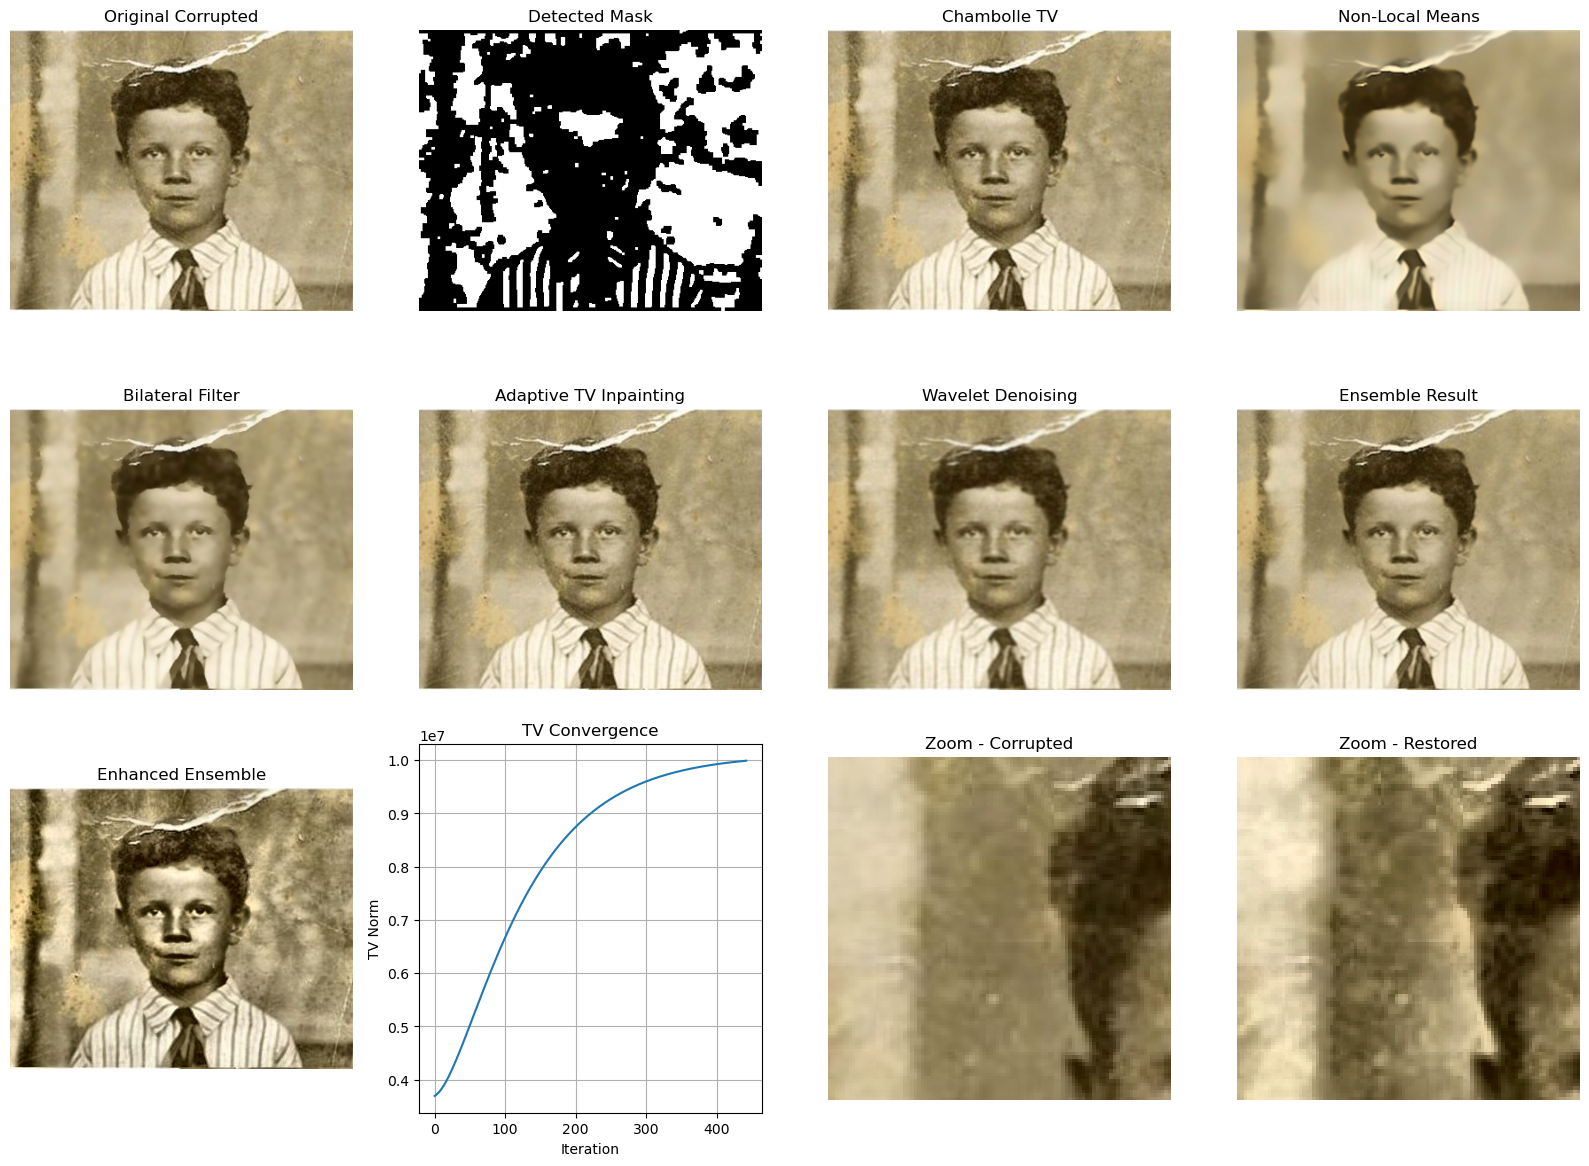


Best result saved as 'restored_image.jpg'


In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from scipy.ndimage import median_filter, gaussian_filter

def chambolle_tv_denoising(f, lambda_tv=0.1, max_iter=100, tol=1e-4):
    """
    Chambolle's algorithm for Total Variation denoising
    More efficient and stable than gradient descent
    
    Parameters:
    - f: noisy image
    - lambda_tv: regularization parameter (smaller = more denoising)
    - max_iter: maximum iterations
    - tol: tolerance for convergence
    """
    u = f.copy().astype(np.float32)
    
    # Initialize dual variables p and q (for x and y gradients)
    if len(u.shape) == 3:
        h, w, c = u.shape
        p = np.zeros((h, w, c), dtype=np.float32)
        q = np.zeros((h, w, c), dtype=np.float32)
        
        for channel in range(c):
            u_channel, p[:, :, channel], q[:, :, channel] = _chambolle_single_channel(
                u[:, :, channel], f[:, :, channel], lambda_tv, max_iter, tol
            )
            u[:, :, channel] = u_channel
    else:
        u, p, q = _chambolle_single_channel(u, f, lambda_tv, max_iter, tol)
    
    return np.clip(u, 0, 255).astype(np.uint8)

def _chambolle_single_channel(u, f, lambda_tv, max_iter, tol):
    """Chambolle's algorithm for a single channel"""
    h, w = u.shape
    p = np.zeros((h, w), dtype=np.float32)
    q = np.zeros((h, w), dtype=np.float32)
    
    tau = 0.25  # Step size for dual variable
    
    for iteration in range(max_iter):
        u_old = u.copy()
        
        # Compute divergence of (p, q)
        div_pq = np.zeros_like(u)
        div_pq[1:, :] += p[1:, :] - p[:-1, :]
        div_pq[:, 1:] += q[:, 1:] - q[:, :-1]
        
        # Update primal variable u
        u = f - lambda_tv * div_pq
        u = np.clip(u, 0, 255)
        
        # Compute gradients of u
        grad_x = np.diff(u, axis=1, append=u[:, -1:])
        grad_y = np.diff(u, axis=0, append=u[-1:, :])
        
        # Update dual variables p, q
        p_new = p + tau * grad_x
        q_new = q + tau * grad_y
        
        # Projection onto L-infinity ball (|(p,q)| <= 1)
        norm = np.sqrt(p_new**2 + q_new**2 + 1e-10)
        mask = norm > 1
        p_new[mask] /= norm[mask]
        q_new[mask] /= norm[mask]
        
        p = p_new
        q = q_new
        
        # Check convergence
        diff = np.linalg.norm(u - u_old) / np.linalg.norm(u_old + 1e-10)
        if diff < tol:
            print(f"  Chambolle converged after {iteration + 1} iterations")
            break
    
    return u, p, q

def adaptive_tv_inpainting(f, mask=None, method='auto', max_iter=1000):
    """
    Adaptive TV inpainting with better mask handling
    """
    if mask is None:
        # Try to create a better mask
        mask = create_adaptive_mask(f)
    
    u = f.copy().astype(np.float32)
    step_size = 0.1
    
    # Adaptive step size
    step_size_decay = 0.99
    
    # Use Chambolle's approach for the TV part
    if len(u.shape) == 3:
        h, w, c = u.shape
        p = np.zeros((h, w, c), dtype=np.float32)
        q = np.zeros((h, w, c), dtype=np.float32)
    else:
        h, w = u.shape
        p = np.zeros((h, w), dtype=np.float32)
        q = np.zeros((h, w), dtype=np.float32)
    
    # Ensure mask is 2D
    if len(mask.shape) > 2:
        mask = mask[:, :, 0]
    
    tv_values = []
    best_u = u.copy()
    best_tv = float('inf')
    
    for iteration in range(max_iter):
        u_old = u.copy()
        
        # Compute gradients of u
        grad_x = np.diff(u, axis=1, append=u[:, -1:])
        grad_y = np.diff(u, axis=0, append=u[-1:, :])
        
        # Update dual variables
        if len(u.shape) == 3:
            for c in range(u.shape[2]):
                p[:, :, c] = p[:, :, c] + step_size * grad_x[:, :, c]
                q[:, :, c] = q[:, :, c] + step_size * grad_y[:, :, c]
                
                # Projection
                norm = np.sqrt(p[:, :, c]**2 + q[:, :, c]**2 + 1e-10)
                mask_norm = norm > 1
                p[mask_norm, c] /= norm[mask_norm]
                q[mask_norm, c] /= norm[mask_norm]
        else:
            p = p + step_size * grad_x
            q = q + step_size * grad_y
            
            # Projection
            norm = np.sqrt(p**2 + q**2 + 1e-10)
            mask_norm = norm > 1
            p[mask_norm] /= norm[mask_norm]
            q[mask_norm] /= norm[mask_norm]
        
        # Compute divergence
        div_pq = np.zeros_like(u)
        if len(u.shape) == 3:
            for c in range(u.shape[2]):
                div_pq[1:, :, c] += p[1:, :, c] - p[:-1, :, c]
                div_pq[:, 1:, c] += q[:, 1:, c] - q[:, :-1, c]
        else:
            div_pq[1:, :] += p[1:, :] - p[:-1, :]
            div_pq[:, 1:] += q[:, 1:] - q[:, :-1]
        
        # Update u
        u_unknown = u - step_size * div_pq
        
        # Enforce constraints
        if len(u.shape) == 3:
            mask_3d = mask[:, :, np.newaxis]
            u_unknown = np.where(mask_3d == 1, f, u_unknown)
        else:
            u_unknown = np.where(mask == 1, f, u_unknown)
        
        u = u_unknown
        
        # Compute TV value
        tv_val = total_variation_norm(u)
        tv_values.append(tv_val)
        
        # Keep best result
        if tv_val < best_tv:
            best_tv = tv_val
            best_u = u.copy()
        
        # Adaptive step size
        step_size *= step_size_decay
        
        # Check convergence
        diff = np.linalg.norm(u - u_old) / np.linalg.norm(u_old + 1e-10)
        if diff < 1e-5:
            print(f"  Adaptive inpainting converged after {iteration + 1} iterations")
            break
            
        if iteration % 100 == 0:
            print(f"  Iteration {iteration}, TV: {tv_val:.4f}, Change: {diff:.6f}")
    
    return np.clip(best_u, 0, 255).astype(np.uint8), tv_values

def create_adaptive_mask(image):
    """
    Create an adaptive mask based on image statistics
    """
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    
    h, w = gray.shape
    
    # Method 1: Local variance analysis
    # Compute local variance
    local_mean = cv2.blur(gray.astype(float), (5, 5))
    local_var = cv2.blur((gray.astype(float) - local_mean)**2, (5, 5))
    
    # Normalize variance
    local_var_norm = local_var / (local_var.max() + 1e-10)
    
    # Method 2: Edge detection
    edges = cv2.Canny(gray, 30, 100)
    edges_dilated = cv2.dilate(edges, np.ones((3,3), np.uint8), iterations=2)
    
    # Method 3: Color anomalies (for color images)
    color_anomaly = np.zeros((h, w))
    if len(image.shape) == 3:
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        # Detect saturated colors
        saturation = hsv[:, :, 1].astype(float) / 255.0
        color_anomaly = saturation > 0.8
    
    # Combine methods
    mask = np.ones((h, w), dtype=np.float32)
    
    # Regions with very high local variance might be corrupted
    mask[local_var_norm > 0.8] = 0
    
    # Regions around edges might be scratches
    mask[edges_dilated > 0] = 0
    
    # Color anomalies
    mask[color_anomaly > 0] = 0
    
    # Clean up mask with morphological operations
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    return mask

def total_variation_norm(u):
    """Compute Total Variation norm"""
    dx = np.diff(u, axis=1, prepend=u[:, :1])
    dy = np.diff(u, axis=0, prepend=u[:1, :])
    tv = np.sum(np.abs(dx)) + np.sum(np.abs(dy))
    return tv

def bilateral_filter_denoise(image, d=9, sigma_color=75, sigma_space=75):
    """
    Use bilateral filtering for edge-preserving denoising
    """
    if len(image.shape) == 3:
        denoised = cv2.bilateralFilter(image, d, sigma_color, sigma_space)
    else:
        denoised = cv2.bilateralFilter(image, d, sigma_color, sigma_space)
    
    return denoised

def non_local_means_denoise(image, h=10, template_window=7, search_window=21):
    """
    Use Non-Local Means denoising
    """
    if len(image.shape) == 3:
        denoised = cv2.fastNlMeansDenoisingColored(image, None, h, h, template_window, search_window)
    else:
        denoised = cv2.fastNlMeansDenoising(image, None, h, template_window, search_window)
    
    return denoised

def wavelet_denoise(image, threshold=0.1):
    """
    Simple wavelet-based denoising using DCT
    """
    from scipy.fftpack import dct, idct
    
    if len(image.shape) == 3:
        denoised = np.zeros_like(image, dtype=np.float32)
        for c in range(3):
            # Apply DCT
            dct_coeff = dct(dct(image[:, :, c].astype(float), axis=0, norm='ortho'), axis=1, norm='ortho')
            
            # Soft thresholding
            dct_coeff = np.where(np.abs(dct_coeff) < threshold, 0, dct_coeff - np.sign(dct_coeff) * threshold)
            
            # Inverse DCT
            denoised[:, :, c] = idct(idct(dct_coeff, axis=1, norm='ortho'), axis=0, norm='ortho')
    else:
        dct_coeff = dct(dct(image.astype(float), axis=0, norm='ortho'), axis=1, norm='ortho')
        dct_coeff = np.where(np.abs(dct_coeff) < threshold, 0, dct_coeff - np.sign(dct_coeff) * threshold)
        denoised = idct(idct(dct_coeff, axis=1, norm='ortho'), axis=0, norm='ortho')
    
    return np.clip(denoised, 0, 255).astype(np.uint8)

def enhance_result(image, method='clahe'):
    """
    Post-processing to enhance the result
    """
    result = image.copy()
    
    if method == 'clahe':
        # Contrast enhancement
        if len(image.shape) == 3:
            lab = cv2.cvtColor(result, cv2.COLOR_BGR2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
            l = clahe.apply(l)
            lab = cv2.merge([l, a, b])
            result = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    
    elif method == 'sharpen':
        # Sharpening
        kernel = np.array([[-1,-1,-1],
                           [-1, 9,-1],
                           [-1,-1,-1]])
        result = cv2.filter2D(result, -1, kernel)
    
    return result

def main():
    # Load your corrupted image
    image_path = 'image_imp.jpg'
    corrupted = cv2.imread(image_path)
    
    if corrupted is None:
        print("Error: Could not load image")
        return
    
    print(f"Image shape: {corrupted.shape}")
    print(f"Image dtype: {corrupted.dtype}")
    
    print("\n" + "="*60)
    print("RESTORING CORRUPTED IMAGE - ADVANCED METHODS")
    print("="*60)
    
    # Method 1: Chambolle TV Denoising
    print("\n1. Applying Chambolle TV Denoising...")
    restored_chambolle = chambolle_tv_denoising(corrupted, lambda_tv=0.15, max_iter=200)
    
    # Method 2: Non-Local Means Denoising
    print("\n2. Applying Non-Local Means Denoising...")
    restored_nlm = non_local_means_denoise(corrupted, h=15)
    
    # Method 3: Bilateral Filter
    print("\n3. Applying Bilateral Filter...")
    restored_bilateral = bilateral_filter_denoise(corrupted)
    
    # Method 4: Adaptive TV Inpainting with mask
    print("\n4. Applying Adaptive TV Inpainting...")
    mask = create_adaptive_mask(corrupted)
    restored_adaptive, tv_vals = adaptive_tv_inpainting(corrupted, mask, max_iter=500)
    
    # Method 5: Wavelet Denoising
    print("\n5. Applying Wavelet Denoising...")
    restored_wavelet = wavelet_denoise(corrupted, threshold=15)
    
    # Ensemble method: Combine best results
    print("\n6. Creating ensemble result...")
    ensemble = np.clip(
        (restored_chambolle.astype(float) + 
         restored_nlm.astype(float) + 
         restored_adaptive.astype(float)) / 3, 
        0, 255
    ).astype(np.uint8)
    
    # Enhance ensemble result
    ensemble_enhanced = enhance_result(ensemble, method='clahe')
    
    # Visualize results
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    # Original
    axes[0, 0].imshow(cv2.cvtColor(corrupted, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Original Corrupted')
    axes[0, 0].axis('off')
    
    # Mask
    axes[0, 1].imshow(mask, cmap='gray')
    axes[0, 1].set_title('Detected Mask')
    axes[0, 1].axis('off')
    
    # Method 1-2
    axes[0, 2].imshow(cv2.cvtColor(restored_chambolle, cv2.COLOR_BGR2RGB))
    axes[0, 2].set_title('Chambolle TV')
    axes[0, 2].axis('off')
    
    axes[0, 3].imshow(cv2.cvtColor(restored_nlm, cv2.COLOR_BGR2RGB))
    axes[0, 3].set_title('Non-Local Means')
    axes[0, 3].axis('off')
    
    # Method 3-4
    axes[1, 0].imshow(cv2.cvtColor(restored_bilateral, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title('Bilateral Filter')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(cv2.cvtColor(restored_adaptive, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title('Adaptive TV Inpainting')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(cv2.cvtColor(restored_wavelet, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title('Wavelet Denoising')
    axes[1, 2].axis('off')
    
    # Ensemble
    axes[1, 3].imshow(cv2.cvtColor(ensemble, cv2.COLOR_BGR2RGB))
    axes[1, 3].set_title('Ensemble Result')
    axes[1, 3].axis('off')
    
    # Enhanced ensemble and differences
    axes[2, 0].imshow(cv2.cvtColor(ensemble_enhanced, cv2.COLOR_BGR2RGB))
    axes[2, 0].set_title('Enhanced Ensemble')
    axes[2, 0].axis('off')
    
    # TV convergence plot
    if 'tv_vals' in locals() and len(tv_vals) > 0:
        axes[2, 1].plot(tv_vals)
        axes[2, 1].set_xlabel('Iteration')
        axes[2, 1].set_ylabel('TV Norm')
        axes[2, 1].set_title('TV Convergence')
        axes[2, 1].grid(True)
    
    # Zoomed comparison
    if corrupted.shape[0] > 100 and corrupted.shape[1] > 100:
        zoom_region = corrupted[50:150, 50:150]
        zoom_restored = ensemble_enhanced[50:150, 50:150]
        
        axes[2, 2].imshow(cv2.cvtColor(zoom_region, cv2.COLOR_BGR2RGB))
        axes[2, 2].set_title('Zoom - Corrupted')
        axes[2, 2].axis('off')
        
        axes[2, 3].imshow(cv2.cvtColor(zoom_restored, cv2.COLOR_BGR2RGB))
        axes[2, 3].set_title('Zoom - Restored')
        axes[2, 3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Save the best result
    cv2.imwrite('restored_image.jpg', ensemble_enhanced)
    print("\nBest result saved as 'restored_image.jpg'")

if __name__ == "__main__":
    main()